In [1]:
from pathlib import Path

from config import PLOTS_DIR
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [2]:
from core.dgp import DGP_EXAMPLES, ARProcess, GARCHProcess, ARGARCHProcess, IIDProcess, StudentTInnov
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES["ar1_normal_"] = lambda phi: ARProcess(phi=phi)
DGP_EXAMPLES["garch_"] = lambda _alpha, beta: GARCHProcess(alpha=_alpha, beta=beta)
DGP_EXAMPLES["ar_garch"] = lambda **kwargs: ARGARCHProcess(phi=-0.3, alpha=0.1, beta=0.85)
DGP_EXAMPLES["iid_t"] = lambda df: IIDProcess(StudentTInnov(df=df))



## Scenarios and parameter grids

In [3]:
# name : (dgp_names, model_short_names)
scenarios = {
    "a_plus_b": (
        ["garch_"], #with normal innovations
        ["garch11"],
    ),
    "phi": (
        ["ar1_normal_"],
        ["ar1_normal"],
    ),
    "sr": (
        ["iid_normal"],
        ["iid_normal", "iid_nonnormal", "ar1_normal"],
    ),
    "slow_conv": (
        ["iid_t"],
        ["iid_student_t"],
    ),
    "efficiency": (
        ["iid_normal"],
        ["iid_normal", "iid_student_t", "iid_nonnormal", "ar1_normal", "ar1_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 0.7, 1.0, 1.2, 1.5, 1.8, 2.0],
    "T":     [100, 300, 500, 1_000, 2_000],
    "n_sim": [1_000, 10_000, 50_000],
}

## Experiment registry

In [4]:
c = 0.1
[(round(sum*c, 3), round(sum*(1-c),3)) for sum in [0.7, 0.8, 0.9, 0.92, 0.95, 0.98]]

[(0.07, 0.63),
 (0.08, 0.72),
 (0.09, 0.81),
 (0.092, 0.828),
 (0.095, 0.855),
 (0.098, 0.882)]

In [5]:
N_SIM  = 50_000
N_JOBS = -1

experiments = {
    "slow_conv": ExperimentSpec(
        scenario   = scenarios["slow_conv"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        sr_default=0.5, #when omitted the default is 0.5
        n_jobs = N_JOBS,
        T_default=100, #when omitted the default is 500
        n_default  = N_SIM,
        th_moments = False,
        label_param  = "df",
        label_values = [50, 6, 4, 3.5, 3],
    ),
    "a_plus_b": ExperimentSpec(
        scenario   = scenarios["a_plus_b"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default  = N_SIM,
        sr_default=0.5,
        n_jobs = N_JOBS,
        th_moments = True,
        label_param  = ("_alpha", "beta"),
        label_values = [(0.07,0.63),(0.08, 0.72),(0.09,0.81),(0.092, 0.828),(0.095, 0.855),(0.098,0.882)],
    ),
    "phi": ExperimentSpec(
        scenario   = scenarios["phi"],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default  = N_SIM,
        sr_default=0.5,
        th_moments = False,
        n_jobs = N_JOBS,
        label_param  = "phi",
        label_values = [-0.6, -0.4, -0.2, 0.2, 0.4, 0.6],
    ),
    "sr": ExperimentSpec(
        scenario   = scenarios["sr"],
        param_name = "sr",
        param_values = parameters["sr"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        T_default=100,
        n_default  = N_SIM,
        th_moments = False,
        n_jobs = N_JOBS,
    ),
    "efficiency": ExperimentSpec(
        scenario   = scenarios["efficiency"],
        # param_name = "n_sim",
        # param_values = [100, 1000, 5000, 10_000, 50_000],
        param_name = "T",
        param_values = parameters["T"],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        #T_default=50,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

---
## EXECUTION

In [ ]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"slow_conv",
        "a_plus_b",
        "phi",
        #"sr",
        #"efficiency",
    ],
)


  Experiment: a_plus_b
  [1/30]  T=100  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [2/30]  T=300  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [3/30]  T=500  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [4/30]  T=1000  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [5/30]  T=2000  ('_alpha', 'beta')=(0.07, 0.63)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [6/30]  T=100  ('_alpha', 'beta')=(0.08, 0.72)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [7/30]  T=300  ('_alpha', 'beta')=(0.08, 0.72)  (TWO_SIDED_COVERAGE)
[info] Using theoretical moments  |  study_type=TWO_SIDED_COVERAGE
  [8/30]

---
## VISUALIZATION

In [ ]:
#common
import numpy as np
import matplotlib.pyplot as plt
from seaborn.palettes import cubehelix_palette

line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)
folder = PLOTS_DIR / "scenarios_add"

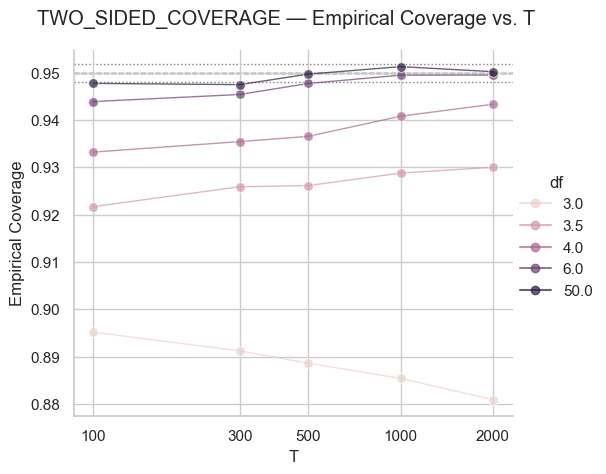

In [19]:
run_analysis(experiments, "slow_conv", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T'], palette=cubehelix_palette(5)
                  ))

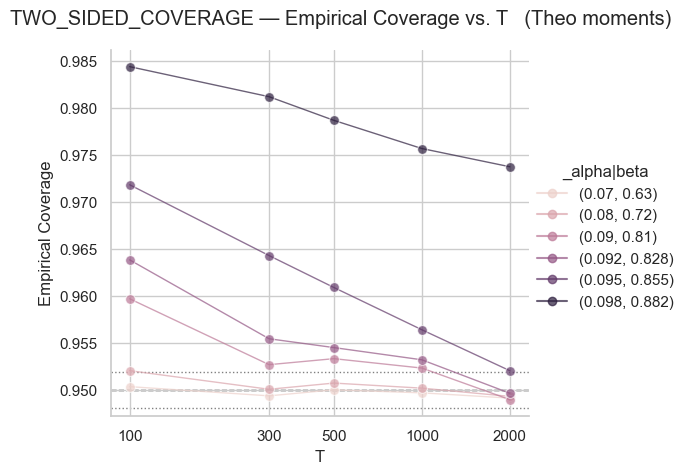

In [ ]:
run_analysis(experiments, "a_plus_b", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T'], palette=cubehelix_palette(6)
                  ))

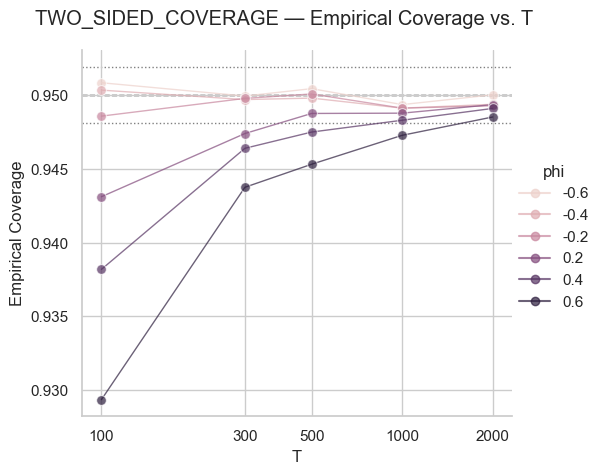

In [30]:
run_analysis(experiments, "phi", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T']))

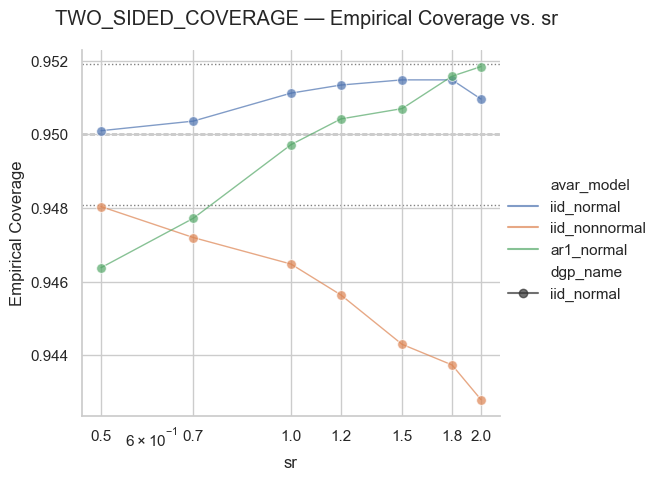

In [31]:
run_analysis(experiments, "sr", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['sr']))

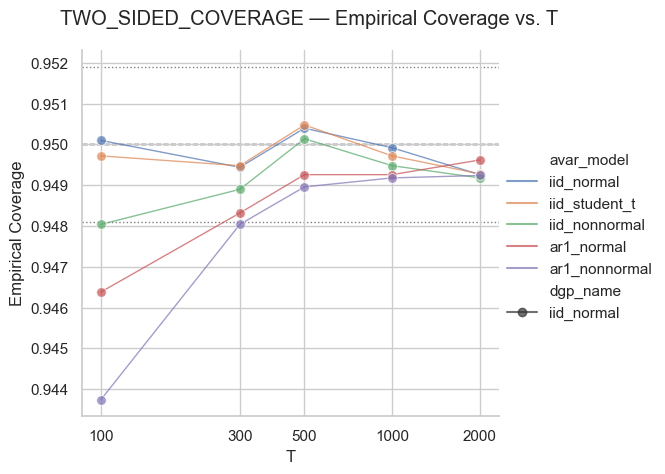

In [32]:
run_analysis(experiments, "efficiency", alpha=0.05, plot_mask=[0,0,1],
             savefig_folder=folder,
             line_plot_kargs=line_plot_kargs | 
             dict(log=True, xticks=parameters['T']))